# Phase 1: Merge US Uncertainty & Markets

This notebook merges US EPU, S&P 500, Gold, and Bitcoin datasets into a unified daily dataframe with calculated returns and volatility features.

**Objective**: Create a clean, feature-rich dataset for volatility analysis and modeling.

**Output**: `data/processed/merged_daily_features.csv`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Paths
DATA_RAW = Path('../../data/raw')
DATA_PROCESSED = Path('../../data/processed')
DATA_PROCESSED.mkdir(exist_ok=True)

## 1. Load and Clean Individual Datasets

### 1.1 US EPU Daily


In [3]:
# Load US EPU
epu_df = pd.read_csv(DATA_RAW / 'us-epu-daily.csv')
print("US EPU shape:", epu_df.shape)
print("\nFirst rows:")
display(epu_df.head())

# Create Date column from day, month, year
epu_df['Date'] = pd.to_datetime(epu_df[['year', 'month', 'day']])

# Rename EPU column for clarity
epu_df = epu_df.rename(columns={'daily_policy_index': 'EPU'})

# Select and sort
epu_df = epu_df[['Date', 'EPU']].sort_values('Date').reset_index(drop=True)

print("\nCleaned EPU:")
display(epu_df.head())
print(f"Date range: {epu_df['Date'].min()} to {epu_df['Date'].max()}")

US EPU shape: (15008, 4)

First rows:


,day,month,year,daily_policy_index
0,1,1,1985,103.83
1,2,1,1985,296.43
2,3,1,1985,56.06
3,4,1,1985,118.45
4,5,1,1985,88.56



Cleaned EPU:


,Date,EPU
0,1985-01-01,103.83
1,1985-01-02,296.43
2,1985-01-03,56.06
3,1985-01-04,118.45
4,1985-01-05,88.56


Date range: 1985-01-01 00:00:00 to 2026-02-02 00:00:00


### 1.2 S&P 500 Daily

In [4]:
# Load S&P 500
sp500_df = pd.read_csv(DATA_RAW / 'sp500-daily.csv')
print("S&P 500 shape:", sp500_df.shape)
print("\nFirst rows (raw):")
display(sp500_df.head())

# Clean column names
sp500_df.columns = ['Date', 'Last', 'Open', 'High', 'Low', 'Vol.', 'Change %']

# Parse date (Spanish format: DD.MM.YYYY)
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'], format='%d.%m.%Y')

# Clean numeric columns (Spanish format: comma as decimal, dot as thousands)
def clean_spanish_number(val):
    if pd.isna(val) or val == '' or val == '-':
        return np.nan
    return float(str(val).replace('.', '').replace(',', '.'))

for col in ['Last', 'Open', 'High', 'Low']:
    sp500_df[col] = sp500_df[col].apply(clean_spanish_number)

# Select relevant columns
sp500_df = sp500_df[['Date', 'Last', 'Open', 'High', 'Low']].sort_values('Date').reset_index(drop=True)
sp500_df = sp500_df.rename(columns={'Last': 'SP500_Close', 'Open': 'SP500_Open', 
                                      'High': 'SP500_High', 'Low': 'SP500_Low'})

print("\nCleaned S&P 500:")
display(sp500_df.head())
print(f"Date range: {sp500_df['Date'].min()} to {sp500_df['Date'].max()}")

S&P 500 shape: (5000, 7)

First rows (raw):


,Fecha,Último,Apertura,Máximo,Mínimo,Vol.,% var.
0,13.11.2023,"4.411,55","4.406,66","4.421,76","4.393,82",NaN,"-0,08%"
1,10.11.2023,"4.415,24","4.364,15","4.418,03","4.353,34",NaN,"1,56%"
2,09.11.2023,"4.347,35","4.391,41","4.393,40","4.343,94",NaN,"-0,81%"
3,08.11.2023,"4.382,78","4.384,37","4.391,20","4.359,76",NaN,"0,10%"
4,07.11.2023,"4.378,38","4.366,21","4.386,26","4.355,41",NaN,"0,28%"



Cleaned S&P 500:


,Date,SP500_Close,SP500_Open,SP500_High,SP500_Low
0,2004-01-05,1122.2,1108.5,1122.2,1108.5
1,2004-01-06,1123.7,1122.2,1124.5,1118.4
2,2004-01-07,1126.3,1123.7,1126.3,1116.5
3,2004-01-08,1131.9,1126.3,1131.9,1124.9
4,2004-01-09,1121.9,1131.9,1131.9,1120.9


Date range: 2004-01-05 00:00:00 to 2023-11-13 00:00:00


### 1.3 Gold Daily

In [5]:
# Load Gold
gold_df = pd.read_csv(DATA_RAW / 'gold-daily.csv')
print("Gold shape:", gold_df.shape)
print("\nFirst rows (raw):")
display(gold_df.head())

# Clean column names
gold_df.columns = ['Date', 'Last', 'Open', 'High', 'Low', 'Vol.', 'Change %']

# Parse date (Spanish format)
gold_df['Date'] = pd.to_datetime(gold_df['Date'], format='%d.%m.%Y')

# Clean numeric columns
for col in ['Last', 'Open', 'High', 'Low']:
    gold_df[col] = gold_df[col].apply(clean_spanish_number)

# Select relevant columns
gold_df = gold_df[['Date', 'Last', 'Open', 'High', 'Low']].sort_values('Date').reset_index(drop=True)
gold_df = gold_df.rename(columns={'Last': 'Gold_Close', 'Open': 'Gold_Open',
                                    'High': 'Gold_High', 'Low': 'Gold_Low'})

print("\nCleaned Gold:")
display(gold_df.head())
print(f"Date range: {gold_df['Date'].min()} to {gold_df['Date'].max()}")

Gold shape: (4966, 7)

First rows (raw):


,Fecha,Último,Apertura,Máximo,Mínimo,Vol.,% var.
0,31.01.2005,"424,10","428,30","428,90","421,50","65,84K","-0,93%"
1,01.02.2005,"422,90","424,30","424,60","421,40","38,34K","-0,28%"
2,02.02.2005,"423,00","422,70","424,70","421,90","22,30K","0,02%"
3,03.02.2005,"418,50","422,80","423,90","416,20","55,31K","-1,06%"
4,04.02.2005,"415,90","418,60","419,50","415,50","49,62K","-0,62%"



Cleaned Gold:


,Date,Gold_Close,Gold_Open,Gold_High,Gold_Low
0,2005-01-31,424.1,428.3,428.9,421.5
1,2005-02-01,422.9,424.3,424.6,421.4
2,2005-02-02,423.0,422.7,424.7,421.9
3,2005-02-03,418.5,422.8,423.9,416.2
4,2005-02-04,415.9,418.6,419.5,415.5


Date range: 2005-01-31 00:00:00 to 2026-02-04 00:00:00


### 1.4 Bitcoin Daily

In [6]:
# Load Bitcoin
btc_df = pd.read_csv(DATA_RAW / 'btc-daily.csv')
print("Bitcoin shape:", btc_df.shape)
print("\nFirst rows (raw):")
display(btc_df.head())

# Clean column names
btc_df.columns = ['Date', 'Last', 'Open', 'High', 'Low', 'Vol.', 'Change %']

# Parse date (Spanish format)
btc_df['Date'] = pd.to_datetime(btc_df['Date'], format='%d.%m.%Y')

# Clean numeric columns
for col in ['Last', 'Open', 'High', 'Low']:
    btc_df[col] = btc_df[col].apply(clean_spanish_number)

# Select relevant columns
btc_df = btc_df[['Date', 'Last', 'Open', 'High', 'Low']].sort_values('Date').reset_index(drop=True)
btc_df = btc_df.rename(columns={'Last': 'BTC_Close', 'Open': 'BTC_Open',
                                  'High': 'BTC_High', 'Low': 'BTC_Low'})

print("\nCleaned Bitcoin:")
display(btc_df.head())
print(f"Date range: {btc_df['Date'].min()} to {btc_df['Date'].max()}")

Bitcoin shape: (4415, 7)

First rows (raw):


,Fecha,Último,Apertura,Máximo,Mínimo,Vol.,% var.
0,03.02.2026,"78.296,2","78.725,6","79.158,4","77.652,4","86,69K","-0,54%"
1,02.02.2026,"78.720,6","76.956,6","79.251,0","74.635,5","124,03K","2,27%"
2,01.02.2026,"76.976,1","78.720,6","79.355,0","75.766,8","76,61K","-2,22%"
3,31.01.2026,"78.726,5","84.227,7","84.240,8","75.993,4","105,81K","-6,54%"
4,30.01.2026,"84.235,5","84.657,0","84.705,1","81.201,5","109,59K","-0,51%"



Cleaned Bitcoin:


,Date,BTC_Close,BTC_Open,BTC_High,BTC_Low
0,2014-01-03,884.3,856.9,888.2,839.4
1,2014-01-04,924.7,884.3,932.2,848.3
2,2014-01-05,1014.7,924.7,1029.9,911.4
3,2014-01-06,1012.7,1014.7,1093.4,964.7
4,2014-01-07,879.9,1012.7,1044.0,879.8


Date range: 2014-01-03 00:00:00 to 2026-02-03 00:00:00


## 2. Calculate Returns and Volatility Features

### 2.1 EPU Features

In [7]:
# Calculate EPU changes and rolling statistics
epu_df['ΔEPU'] = epu_df['EPU'].diff()
epu_df['EPU_MA30'] = epu_df['EPU'].rolling(window=30).mean()
epu_df['EPU_Std30'] = epu_df['EPU'].rolling(window=30).std()

print("EPU features:")
display(epu_df.head(35))
print("\nEPU features summary:")
display(epu_df[['EPU', 'ΔEPU', 'EPU_MA30', 'EPU_Std30']].describe())

EPU features:


,Date,EPU,ΔEPU,EPU_MA30,EPU_Std30
0,1985-01-01,103.83,NaN,NaN,NaN
1,1985-01-02,296.43,192.60,NaN,NaN
2,1985-01-03,56.06,-240.37,NaN,NaN
3,1985-01-04,118.45,62.39,NaN,NaN
4,1985-01-05,88.56,-29.89,NaN,NaN
5,1985-01-06,206.51,117.95,NaN,NaN
6,1985-01-07,593.28,386.77,NaN,NaN
7,1985-01-08,237.04,-356.24,NaN,NaN
8,1985-01-09,103.83,-133.21,NaN,NaN
9,1985-01-10,201.74,97.91,NaN,NaN



EPU features summary:


,EPU,ΔEPU,EPU_MA30,EPU_Std30
count,15008.000000,15007.000000,14979.000000,14979.000000
mean,116.799588,0.000372,116.546300,55.362237
std,93.420367,76.940071,70.971474,26.389217
min,3.320000,-952.780000,33.599667,13.305275
25%,58.070000,-35.720000,74.343500,36.437548
50%,91.155000,-1.250000,97.301667,48.964934
75%,144.087500,35.025000,134.665833,66.174962
max,1026.380000,872.820000,585.827000,196.464810


### 2.2 Asset Returns and Volatility

For each asset, calculate:
- **Log returns**: `log(Close_t / Close_{t-1})`
- **Rolling volatility**: 7-day, 30-day, 90-day windows

In [8]:
def calculate_asset_features(df, asset_name):
    """
    Calculate returns and volatility features for an asset.
    
    Parameters:
    - df: DataFrame with Date and {asset_name}_Close columns
    - asset_name: Name prefix (e.g., 'SP500', 'Gold', 'BTC')
    
    Returns:
    - DataFrame with added features
    """
    close_col = f'{asset_name}_Close'
    
    # Log returns
    df[f'{asset_name}_Return'] = np.log(df[close_col] / df[close_col].shift(1))
    
    # Rolling volatility (std of returns)
    df[f'{asset_name}_Vol7d'] = df[f'{asset_name}_Return'].rolling(window=7).std()
    df[f'{asset_name}_Vol30d'] = df[f'{asset_name}_Return'].rolling(window=30).std()
    df[f'{asset_name}_Vol90d'] = df[f'{asset_name}_Return'].rolling(window=90).std()
    
    return df

# Calculate features for each asset
sp500_df = calculate_asset_features(sp500_df, 'SP500')
gold_df = calculate_asset_features(gold_df, 'Gold')
btc_df = calculate_asset_features(btc_df, 'BTC')

print("S&P 500 features:")
display(sp500_df.head(95))
print("\nGold features:")
display(gold_df.head(95))
print("\nBitcoin features:")
display(btc_df.head(95))

S&P 500 features:


,Date,SP500_Close,SP500_Open,SP500_High,SP500_Low,SP500_Return,SP500_Vol7d,SP500_Vol30d,SP500_Vol90d
0,2004-01-05,1122.2,1108.5,1122.2,1108.5,NaN,NaN,NaN,NaN
1,2004-01-06,1123.7,1122.2,1124.5,1118.4,0.001336,NaN,NaN,NaN
2,2004-01-07,1126.3,1123.7,1126.3,1116.5,0.002311,NaN,NaN,NaN
3,2004-01-08,1131.9,1126.3,1131.9,1124.9,0.004960,NaN,NaN,NaN
4,2004-01-09,1121.9,1131.9,1131.9,1120.9,-0.008874,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
90,2004-05-13,1096.4,1097.3,1102.8,1091.8,-0.000821,0.007666,0.007688,0.007605
91,2004-05-14,1095.7,1096.4,1102.4,1088.2,-0.000639,0.007467,0.007598,0.007603
92,2004-05-17,1084.1,1095.7,1095.7,1079.4,-0.010643,0.007900,0.007571,0.007676
93,2004-05-18,1091.5,1084.1,1094.1,1084.1,0.006803,0.007406,0.007535,0.007693



Gold features:


,Date,Gold_Close,Gold_Open,Gold_High,Gold_Low,Gold_Return,Gold_Vol7d,Gold_Vol30d,Gold_Vol90d
0,2005-01-31,424.1,428.3,428.9,421.5,NaN,NaN,NaN,NaN
1,2005-02-01,422.9,424.3,424.6,421.4,-0.002834,NaN,NaN,NaN
2,2005-02-02,423.0,422.7,424.7,421.9,0.000236,NaN,NaN,NaN
3,2005-02-03,418.5,422.8,423.9,416.2,-0.010695,NaN,NaN,NaN
4,2005-02-04,415.9,418.6,419.5,415.5,-0.006232,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
90,2005-06-09,426.1,426.2,427.1,423.0,-0.001173,0.007196,0.006126,0.006771
91,2005-06-10,429.3,425.9,430.5,424.1,0.007482,0.006985,0.006266,0.006809
92,2005-06-13,431.1,428.8,432.6,426.3,0.004184,0.004130,0.006105,0.006822
93,2005-06-14,429.3,431.1,431.1,428.3,-0.004184,0.004756,0.005680,0.006739



Bitcoin features:


,Date,BTC_Close,BTC_Open,BTC_High,BTC_Low,BTC_Return,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
0,2014-01-03,884.3,856.9,888.2,839.4,NaN,NaN,NaN,NaN
1,2014-01-04,924.7,884.3,932.2,848.3,0.044673,NaN,NaN,NaN
2,2014-01-05,1014.7,924.7,1029.9,911.4,0.092879,NaN,NaN,NaN
3,2014-01-06,1012.7,1014.7,1093.4,964.7,-0.001973,NaN,NaN,NaN
4,2014-01-07,879.9,1012.7,1044.0,879.8,-0.140567,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
90,2014-04-03,436.3,424.4,448.7,386.7,0.027654,0.052375,0.046464,0.221502
91,2014-04-04,444.4,436.3,456.5,415.5,0.018395,0.048382,0.046815,0.221449
92,2014-04-05,456.6,444.4,461.2,439.4,0.027083,0.050568,0.047382,0.221221
93,2014-04-06,455.7,456.6,472.4,446.3,-0.001973,0.043382,0.046852,0.221221


## 3. Merge Datasets

In [9]:
# Start with EPU as base
merged_df = epu_df.copy()

# Inner join with S&P 500
merged_df = merged_df.merge(sp500_df, on='Date', how='inner')
print(f"After S&P 500 merge: {len(merged_df)} rows")

# Inner join with Gold
merged_df = merged_df.merge(gold_df, on='Date', how='inner')
print(f"After Gold merge: {len(merged_df)} rows")

# Inner join with Bitcoin
merged_df = merged_df.merge(btc_df, on='Date', how='inner')
print(f"After Bitcoin merge: {len(merged_df)} rows")

# Sort by date
merged_df = merged_df.sort_values('Date').reset_index(drop=True)

print("\nMerged dataset shape:", merged_df.shape)
print(f"Date range: {merged_df['Date'].min()} to {merged_df['Date'].max()}")
print("\nFirst rows:")
display(merged_df.head())
print("\nLast rows:")
display(merged_df.tail())

After S&P 500 merge: 5000 rows
After Gold merge: 4442 rows
After Bitcoin merge: 2227 rows

Merged dataset shape: (2227, 29)
Date range: 2014-01-03 00:00:00 to 2023-11-13 00:00:00

First rows:


,Date,EPU,ΔEPU,EPU_MA30,EPU_Std30,SP500_Close,SP500_Open,SP500_High,SP500_Low,SP500_Return,...,Gold_Vol30d,Gold_Vol90d,BTC_Close,BTC_Open,BTC_High,BTC_Low,BTC_Return,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
0,2014-01-03,113.11,10.03,92.407333,34.711893,1831.4,1833.2,1838.2,1829.1,-0.000328,...,0.012946,0.013518,884.3,856.9,888.2,839.4,NaN,NaN,NaN,NaN
1,2014-01-06,121.14,-23.77,96.903000,35.432950,1826.8,1832.3,1837.2,1823.7,-0.002515,...,0.012768,0.013340,1012.7,1014.7,1093.4,964.7,-0.001973,NaN,NaN,NaN
2,2014-01-07,93.88,-27.26,97.600667,35.149982,1837.9,1828.7,1840.1,1828.7,0.006058,...,0.012657,0.013351,879.9,1012.7,1044.0,879.8,-0.140567,NaN,NaN,NaN
3,2014-01-08,106.42,12.54,98.890667,34.723101,1837.5,1837.9,1840.0,1831.4,-0.000218,...,0.012667,0.013350,938.8,879.9,966.9,858.9,0.064794,NaN,NaN,NaN
4,2014-01-09,60.31,-46.11,97.618667,35.430783,1838.1,1839.0,1843.2,1830.4,0.000326,...,0.012680,0.013313,937.0,938.8,964.6,866.5,-0.001919,NaN,NaN,NaN



Last rows:


,Date,EPU,ΔEPU,EPU_MA30,EPU_Std30,SP500_Close,SP500_Open,SP500_High,SP500_Low,SP500_Return,...,Gold_Vol30d,Gold_Vol90d,BTC_Close,BTC_Open,BTC_High,BTC_Low,BTC_Return,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
2222,2023-11-06,342.88,257.61,144.437667,107.215802,4365.98,4364.27,4372.21,4347.53,0.001751,...,0.009369,0.007859,35042.0,35020.3,35275.6,34742.9,0.000645,0.011610,0.022225,0.019976
2223,2023-11-07,122.59,-220.29,140.894000,106.078748,4378.38,4366.21,4386.26,4355.41,0.002836,...,0.009507,0.007818,35426.1,35042.1,35877.9,34536.9,0.010901,0.012043,0.022168,0.019978
2224,2023-11-08,119.34,-3.25,136.067667,103.541926,4382.78,4384.37,4391.20,4359.76,0.001004,...,0.009459,0.007753,35636.9,35426.2,36050.2,35148.8,0.005933,0.008975,0.021842,0.019971
2225,2023-11-09,142.71,23.37,136.049000,103.540633,4347.35,4391.41,4393.40,4343.94,-0.008117,...,0.009516,0.007776,36700.5,35636.9,37942.0,35578.1,0.029409,0.011609,0.021962,0.020174
2226,2023-11-13,116.21,-28.83,133.770667,101.984184,4411.55,4406.66,4421.76,4393.82,-0.000836,...,0.009630,0.007812,36478.3,37067.8,37404.6,36358.4,-0.015939,0.014887,0.021862,0.020294


## 4. Data Quality Checks

In [10]:
# Check missing values
print("Missing values by column:")
missing = merged_df.isnull().sum()
missing_pct = (missing / len(merged_df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
display(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

# Expected NaN pattern for rolling windows
print("\nExpected NaN counts for rolling windows:")
print("- First 1 row: Returns (lag 1)")
print("- First 7 rows: 7-day volatility")
print("- First 30 rows: 30-day volatility and EPU features")
print("- First 90 rows: 90-day volatility")

Missing values by column:


,Missing,Percentage
BTC_Vol90d,60,2.694207
BTC_Vol30d,19,0.853166
BTC_Vol7d,5,0.224517
BTC_Return,1,0.044903



Expected NaN counts for rolling windows:
- First 1 row: Returns (lag 1)
- First 7 rows: 7-day volatility
- First 30 rows: 30-day volatility and EPU features
- First 90 rows: 90-day volatility


In [11]:
# Check for extreme outliers in returns (potential calculation errors)
print("Returns summary statistics:")
return_cols = [col for col in merged_df.columns if 'Return' in col]
display(merged_df[return_cols].describe())

# Check for negative volatility (should not exist)
vol_cols = [col for col in merged_df.columns if 'Vol' in col]
print("\nVolatility summary statistics:")
display(merged_df[vol_cols].describe())

# Verify no negative volatility
for col in vol_cols:
    neg_count = (merged_df[col] < 0).sum()
    if neg_count > 0:
        print(f"⚠️ WARNING: {col} has {neg_count} negative values!")
    else:
        print(f"✓ {col}: All non-negative")

Returns summary statistics:


,SP500_Return,Gold_Return,BTC_Return
count,2227.000000,2227.000000,2226.000000
mean,0.000306,0.000250,0.000795
std,0.011332,0.009602,0.056960
min,-0.127657,-0.051140,-0.848829
25%,-0.003912,-0.004515,-0.014548
50%,0.000533,0.000157,0.000706
75%,0.005586,0.005363,0.018604
max,0.089671,0.057754,1.474180



Volatility summary statistics:


,SP500_Vol7d,SP500_Vol30d,SP500_Vol90d,Gold_Vol7d,Gold_Vol30d,Gold_Vol90d,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
count,2227.000000,2227.000000,2227.000000,2227.000000,2227.000000,2227.000000,2222.000000,2208.000000,2167.000000
mean,0.008962,0.009483,0.009924,0.008782,0.009290,0.009504,0.033794,0.037870,0.038642
std,0.007299,0.006357,0.005579,0.004055,0.002803,0.002152,0.040698,0.037359,0.026508
min,0.001073,0.002244,0.003507,0.001936,0.004496,0.006195,0.002766,0.007046,0.011736
25%,0.004732,0.005934,0.006864,0.006145,0.007358,0.007788,0.017905,0.023594,0.027174
50%,0.007203,0.007841,0.008573,0.008017,0.008705,0.009030,0.027240,0.032211,0.033663
75%,0.011023,0.011341,0.011577,0.010477,0.010348,0.010840,0.040755,0.042366,0.041765
max,0.086525,0.054091,0.034246,0.034861,0.026443,0.017585,0.808068,0.382500,0.222335


✓ SP500_Vol7d: All non-negative
✓ SP500_Vol30d: All non-negative
✓ SP500_Vol90d: All non-negative
✓ Gold_Vol7d: All non-negative
✓ Gold_Vol30d: All non-negative
✓ Gold_Vol90d: All non-negative
✓ BTC_Vol7d: All non-negative
✓ BTC_Vol30d: All non-negative
✓ BTC_Vol90d: All non-negative


In [12]:
# Check date continuity
date_diffs = merged_df['Date'].diff()
print("Date differences (trading days):")
print(date_diffs.value_counts().sort_index().head(10))

# Identify large gaps (> 7 days)
large_gaps = merged_df[date_diffs > pd.Timedelta(days=7)]
if len(large_gaps) > 0:
    print("\nLarge gaps (> 7 days):")
    display(large_gaps[['Date']].head(10))
else:
    print("\n✓ No large gaps in dates")

Date differences (trading days):
Date
1 days    1701
2 days       8
3 days     241
4 days     221
5 days      53
6 days       2
Name: count, dtype: int64

✓ No large gaps in dates


## 5. Feature Overview and Correlations

In [13]:
# List all features
print("All columns in merged dataset:")
for i, col in enumerate(merged_df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\nTotal features: {len(merged_df.columns)}")

All columns in merged dataset:
 1. Date
 2. EPU
 3. ΔEPU
 4. EPU_MA30
 5. EPU_Std30
 6. SP500_Close
 7. SP500_Open
 8. SP500_High
 9. SP500_Low
10. SP500_Return
11. SP500_Vol7d
12. SP500_Vol30d
13. SP500_Vol90d
14. Gold_Close
15. Gold_Open
16. Gold_High
17. Gold_Low
18. Gold_Return
19. Gold_Vol7d
20. Gold_Vol30d
21. Gold_Vol90d
22. BTC_Close
23. BTC_Open
24. BTC_High
25. BTC_Low
26. BTC_Return
27. BTC_Vol7d
28. BTC_Vol30d
29. BTC_Vol90d

Total features: 29


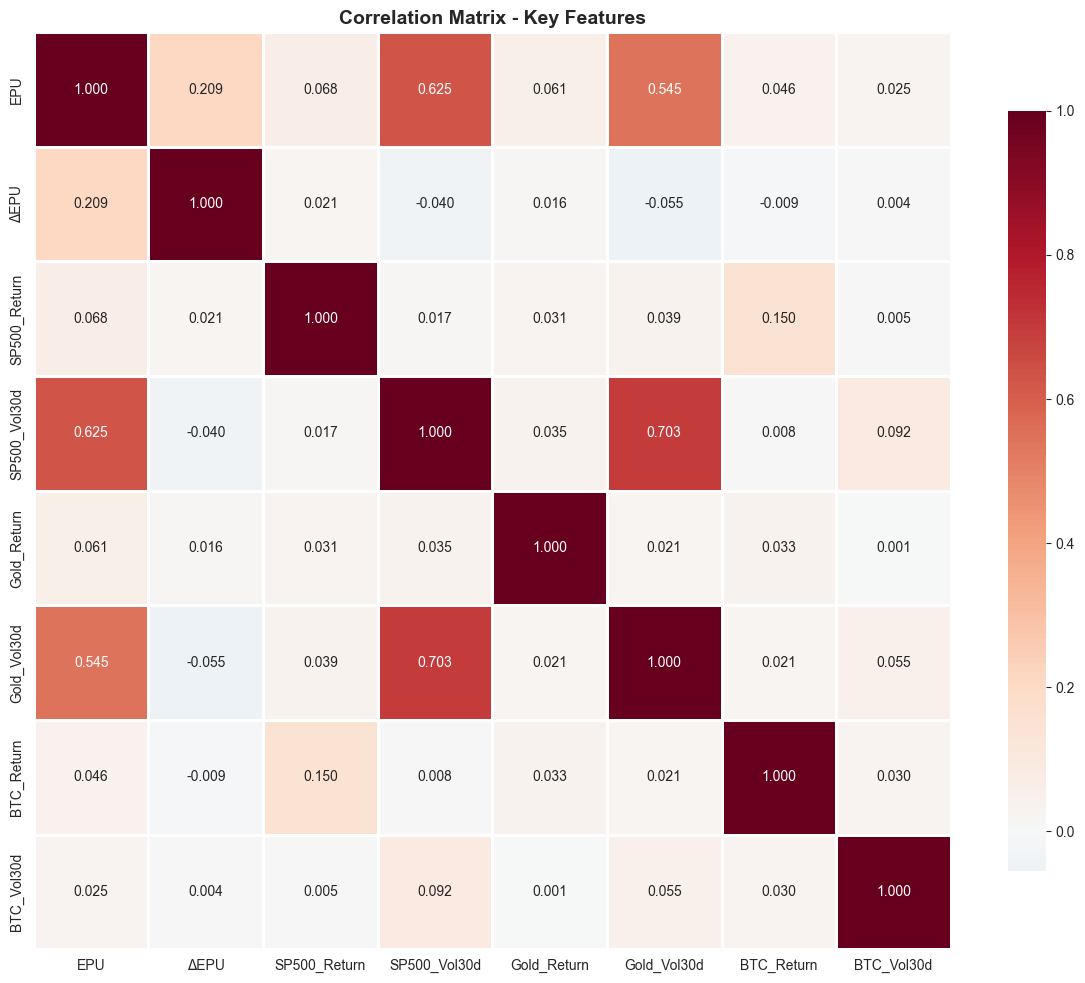

In [14]:
# Correlation matrix for key features
key_features = ['EPU', 'ΔEPU', 'SP500_Return', 'SP500_Vol30d', 
                'Gold_Return', 'Gold_Vol30d', 'BTC_Return', 'BTC_Vol30d']

corr_matrix = merged_df[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Visualize Key Relationships

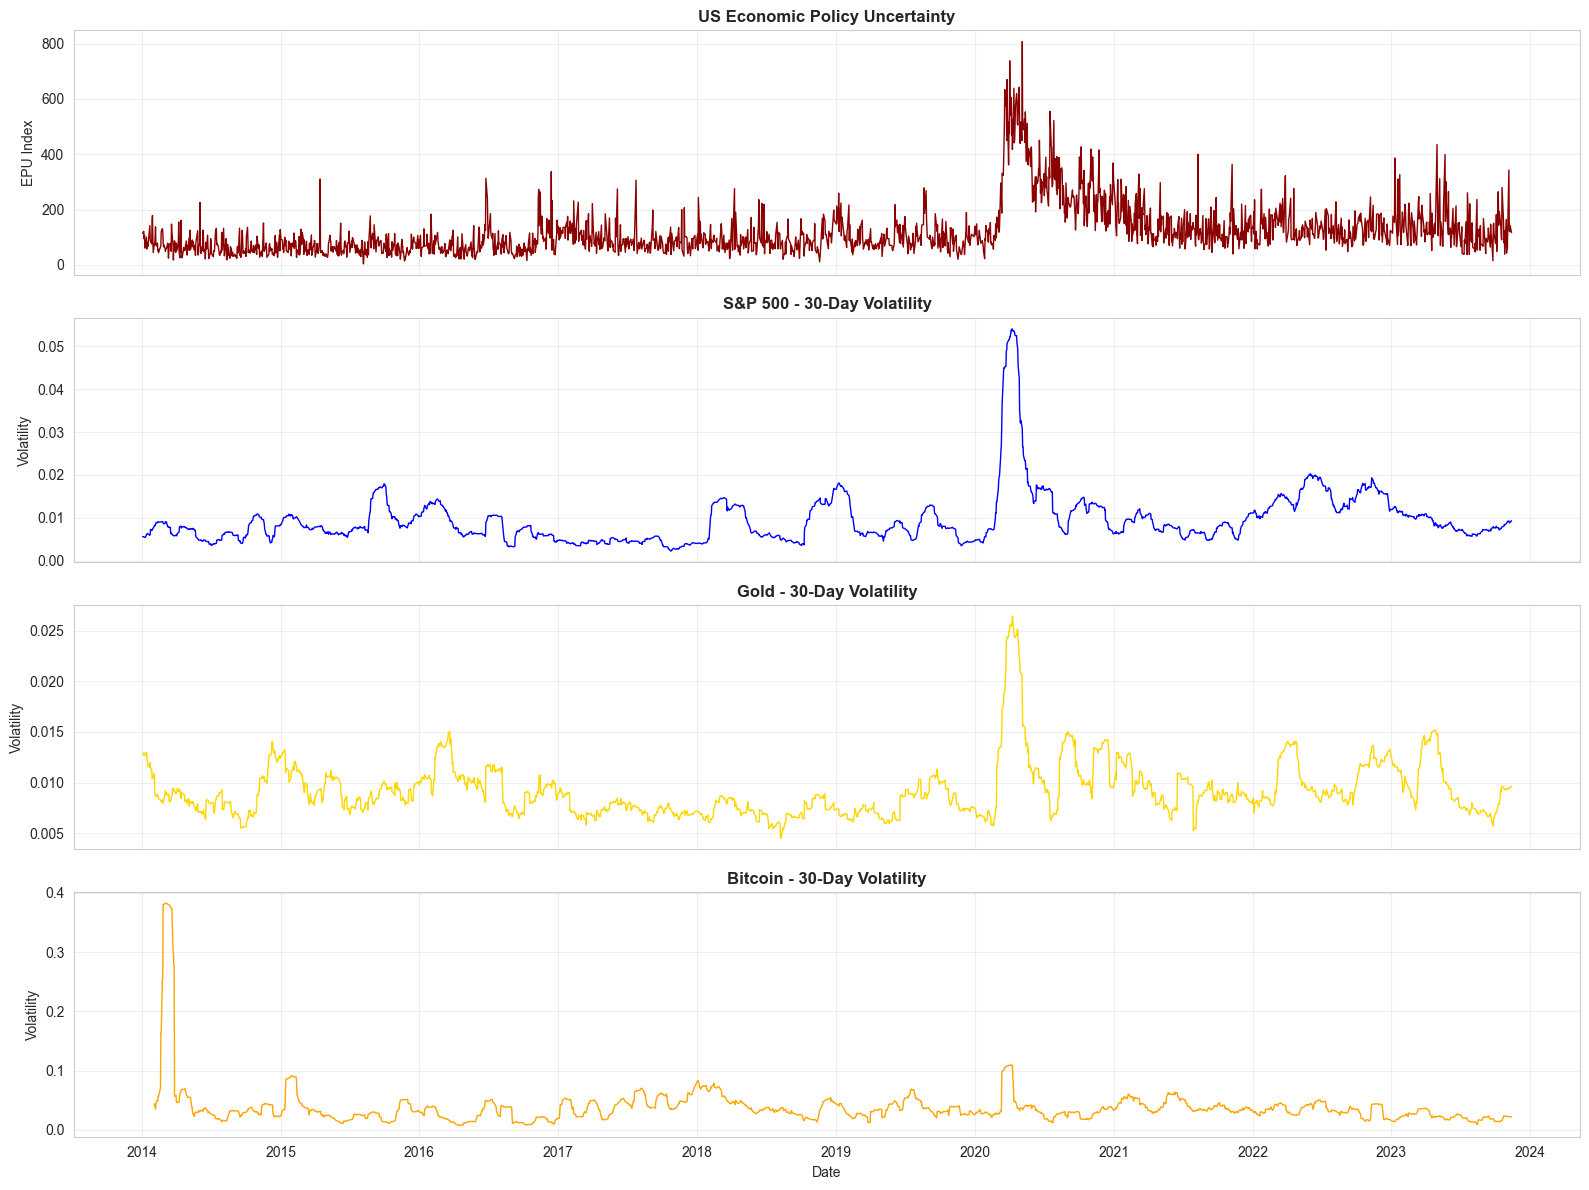

In [15]:
# Plot EPU and asset volatilities over time
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# EPU
axes[0].plot(merged_df['Date'], merged_df['EPU'], linewidth=1, color='darkred')
axes[0].set_title('US Economic Policy Uncertainty', fontsize=12, fontweight='bold')
axes[0].set_ylabel('EPU Index')
axes[0].grid(True, alpha=0.3)

# S&P 500 Volatility
axes[1].plot(merged_df['Date'], merged_df['SP500_Vol30d'], linewidth=1, color='blue')
axes[1].set_title('S&P 500 - 30-Day Volatility', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].grid(True, alpha=0.3)

# Gold Volatility
axes[2].plot(merged_df['Date'], merged_df['Gold_Vol30d'], linewidth=1, color='gold')
axes[2].set_title('Gold - 30-Day Volatility', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Volatility')
axes[2].grid(True, alpha=0.3)

# Bitcoin Volatility
axes[3].plot(merged_df['Date'], merged_df['BTC_Vol30d'], linewidth=1, color='orange')
axes[3].set_title('Bitcoin - 30-Day Volatility', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Volatility')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save Processed Dataset

In [16]:
# Save to CSV
output_file = DATA_PROCESSED / 'merged_daily_features.csv'
merged_df.to_csv(output_file, index=False)

print(f"✓ Saved merged dataset to: {output_file}")
print(f"  - Rows: {len(merged_df):,}")
print(f"  - Columns: {len(merged_df.columns)}")
print(f"  - Date range: {merged_df['Date'].min()} to {merged_df['Date'].max()}")
print(f"  - File size: {output_file.stat().st_size / 1024:.1f} KB")

✓ Saved merged dataset to: ../../data/processed/merged_daily_features.csv
  - Rows: 2,227
  - Columns: 29
  - Date range: 2014-01-03 00:00:00 to 2023-11-13 00:00:00
  - File size: 875.2 KB


## 8. Summary

In [17]:
print("=" * 80)
print("DATA CLEANING AND PREPARATION - SUMMARY")
print("=" * 80)
print(f"\n✓ Successfully merged 4 datasets:")
print(f"  1. US EPU Daily")
print(f"  2. S&P 500 Daily")
print(f"  3. Gold Daily")
print(f"  4. Bitcoin Daily")
print(f"\n✓ Final dataset:")
print(f"  - Observations: {len(merged_df):,}")
print(f"  - Features: {len(merged_df.columns)}")
print(f"  - Date range: {merged_df['Date'].min().strftime('%Y-%m-%d')} to {merged_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"\n✓ Feature categories:")
print(f"  - EPU features: 4 (EPU, ΔEPU, EPU_MA30, EPU_Std30)")
print(f"  - S&P 500 features: 8 (OHLC + Return + 3 volatility windows)")
print(f"  - Gold features: 8 (OHLC + Return + 3 volatility windows)")
print(f"  - Bitcoin features: 8 (OHLC + Return + 3 volatility windows)")
print(f"\n✓ Output file: {output_file}")
print(f"\n✓ Ready for volatility analysis and modeling!")
print("\n" + "=" * 80)

DATA CLEANING AND PREPARATION - SUMMARY

✓ Successfully merged 4 datasets:
  1. US EPU Daily
  2. S&P 500 Daily
  3. Gold Daily
  4. Bitcoin Daily

✓ Final dataset:
  - Observations: 2,227
  - Features: 29
  - Date range: 2014-01-03 to 2023-11-13

✓ Feature categories:
  - EPU features: 4 (EPU, ΔEPU, EPU_MA30, EPU_Std30)
  - S&P 500 features: 8 (OHLC + Return + 3 volatility windows)
  - Gold features: 8 (OHLC + Return + 3 volatility windows)
  - Bitcoin features: 8 (OHLC + Return + 3 volatility windows)

✓ Output file: ../../data/processed/merged_daily_features.csv

✓ Ready for volatility analysis and modeling!

